In [4]:
# Path setup (run first)
import os, sys
from pathlib import Path

CWD = Path.cwd()
# Resolve repository root that contains 'src/' directory
if (CWD / 'src').exists():
    ROOT = CWD
elif (CWD.parent / 'src').exists():
    ROOT = CWD.parent
else:
    ROOT = CWD
    for _ in range(6):
        if (ROOT / 'src').exists():
            break
        ROOT = ROOT.parent

SRC = ROOT / 'src'
LIB_SRC = SRC / 'lib' / 'src'

# Ensure both the repository root (so 'src' package works) and the src subdirs are on sys.path
for p in [ROOT, SRC, LIB_SRC]:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Also set PYTHONPATH for any subprocesses spawned later
parts = [os.environ.get('PYTHONPATH', ''), str(ROOT), str(SRC), str(LIB_SRC)]
os.environ['PYTHONPATH'] = os.pathsep.join([p for p in parts if p])

print('Resolved ROOT:', ROOT)
print('Contains src?:', (ROOT / 'src').exists())
print('sys.path[0:5]:', sys.path[:5])


Resolved ROOT: /scratch/alaforgu/longitudinal_experiments/RlVAE
Contains src?: True
sys.path[0:5]: ['/scratch/alaforgu/longitudinal_experiments/RlVAE', '/scratch/alaforgu/miniconda3/lib/python312.zip', '/scratch/alaforgu/miniconda3/lib/python3.12', '/scratch/alaforgu/miniconda3/lib/python3.12/lib-dynload', '']


In [5]:
# 1. Hydra Configuration (robust absolute config dir)
import os
from pathlib import Path
import hydra
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf

# Resolve project root and conf dir
try:
    PROJECT_ROOT = ROOT  # from first cell
except NameError:
    # Fallback: climb up until 'src' is found
    cwd = Path.cwd()
    PROJECT_ROOT = cwd
    for _ in range(6):
        if (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT / 'conf').exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

CONF_DIR_ABS = str((PROJECT_ROOT / 'conf').resolve())
print('Using CONF_DIR:', CONF_DIR_ABS)

base_overrides = [
    'experiment=single_run',
    'training=quick',
    'visualization=minimal',
]

with initialize_config_dir(version_base=None, config_dir=CONF_DIR_ABS):
    cfg = compose(config_name='config', overrides=base_overrides)

print(OmegaConf.to_yaml(cfg)[:1000])


Using CONF_DIR: /scratch/alaforgu/longitudinal_experiments/RlVAE/conf
model:
  _target_: models.modular_rlvae.ModularRiemannianFlowVAE
  input_dim:
  - 3
  - 64
  - 64
  latent_dim: 16
  n_flows: 8
  flow_hidden_size: 256
  flow_n_blocks: 2
  flow_n_hidden: 1
  epsilon: 1.0e-06
  encoder:
    architecture: mlp
  decoder:
    architecture: mlp
  beta: 1.0
  riemannian_beta: 8.0
  posterior:
    type: riemannian_metric
  sampling:
    method: geodesic
    use_riemannian: true
  loop:
    mode: open
    penalty: 5.0
  metric:
    path: metric_T0.7_scaled.pt
    temperature_override: 3.0
  pretrained:
    encoder_path: data/pretrained/encoder.pt
    decoder_path: data/pretrained/decoder.pt
    metric_path: data/pretrained/${model.metric.path}
training:
  trainer:
    max_epochs: 200
    accelerator: gpu
    devices: 1
    strategy: auto
    precision: 16-mixed
    log_every_n_steps: 1
    val_check_interval: 0.5
    num_sanity_val_steps: 2
    enable_progress_bar: true
    enable_model_sum

In [6]:
# Path setup (run first)
import os, sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# If notebook is under notebooks/, adjust root
if (PROJECT_ROOT / 'src').exists():
    ROOT = PROJECT_ROOT
elif (PROJECT_ROOT.parent / 'src').exists():
    ROOT = PROJECT_ROOT.parent
else:
    # Fallback: ascend until src/ is found
    ROOT = PROJECT_ROOT
    for _ in range(5):
        if (ROOT / 'src').exists():
            break
        ROOT = ROOT.parent

SRC = ROOT / 'src'
LIB_SRC = SRC / 'lib' / 'src'
for p in [SRC, LIB_SRC]:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Also set PYTHONPATH for subprocesses if needed
os.environ['PYTHONPATH'] = os.pathsep.join(filter(None, [os.environ.get('PYTHONPATH',''), str(SRC), str(LIB_SRC)]))

print('Resolved project root:', ROOT)
print('Src exists:', SRC.exists())


Resolved project root: /scratch/alaforgu/longitudinal_experiments/RlVAE
Src exists: True


In [7]:
# Imports (after path setup)
import torch
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf

from models.modular_rlvae import ModularRiemannianFlowVAE
from training.lightning_trainer import LightningRlVAETrainer
from data.cyclic_dataset import CyclicSpritesDataModule
from visualizations.manager import VisualizationManager

print('CUDA available:', torch.cuda.is_available())


/scratch/alaforgu/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True


# RlVAE Pipeline Diagnostics Notebook

This notebook provides an exhaustive diagnostic walkthrough of the RlVAE pipeline, aligned with the project rules and your modeling plan. It validates configuration composition, data, model components (encoder/decoder, metric tensor, flows), RHMC posterior setup, forward pass integrity, and optional short training sanity checks.

Sections:
- 0. Environment & Imports
- 1. Hydra Configuration (compose + overrides)
- 2. Data Diagnostics (summary + sample grid)
- 3. Model Build & Summary
- 4. Metric Tensor Diagnostics (G, G⁻¹, logdet, eigenvalues)
- 5. Flow Diagnostics (params, log-det samples)
- 6. Posterior RHMC Hooks (presence + quick exercise)
- 7. Forward Pass Sanity (shapes + losses)
- 8. Optional Fast Dev Training (very short)
- 9. Metric Normalizer (log Z(ψ)) via anchor set approximation
- 10. Alternating Schedule Helper (Stage A/B/C outline)
- 11. Quick Checks & Exports

Use the configuration cell to switch between minimal/quick/production presets without editing code.


In [8]:
# 0. Environment & Imports
import os
import sys
from pathlib import Path

# Use resolved repository root from the first cell
PROJECT_ROOT = ROOT
SRC = PROJECT_ROOT / 'src'
LIB_SRC = SRC / 'lib' / 'src'
for p in [SRC, LIB_SRC]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import torch
import matplotlib.pyplot as plt
import numpy as np

from omegaconf import OmegaConf

# Core modules
from models.modular_rlvae import ModularRiemannianFlowVAE
from training.lightning_trainer import LightningRlVAETrainer
from data.cyclic_dataset import CyclicSpritesDataModule
from visualizations.manager import VisualizationManager

print('CUDA available:', torch.cuda.is_available())
print('Project root:', PROJECT_ROOT)

CUDA available: True
Project root: /scratch/alaforgu/longitudinal_experiments/RlVAE


📊 CyclicSpritesDataModule initialized
   Train path: data/processed/Sprites_train_cyclic.pt
   Test path: data/processed/Sprites_test_cyclic.pt
   Verify cyclicity: True
   Cyclicity threshold: 0.01
Loading cyclic sprites data from data/processed/Sprites_train_cyclic.pt...
Cyclic sprites data shape: torch.Size([3000, 8, 3, 64, 64])
Data range: [0.000, 0.996]
✅ train cyclic dataset size: 100
✅ Final data shape: torch.Size([100, 8, 3, 64, 64])
✅ Final data range: [0.000, 0.996]
[AUTO] Detected sequence length: 8
🔍 Verifying cyclicity of first 5 sequences:
   Seq 0: MSE = 0.00e+00 ✅
   Seq 1: MSE = 0.00e+00 ✅
   Seq 2: MSE = 0.00e+00 ✅
   Seq 3: MSE = 0.00e+00 ✅
   Seq 4: MSE = 0.00e+00 ✅
Loading cyclic sprites data from data/processed/Sprites_test_cyclic.pt...
Cyclic sprites data shape: torch.Size([888, 8, 3, 64, 64])
Data range: [0.000, 0.996]
✅ val cyclic dataset size: 50
✅ Final data shape: torch.Size([50, 8, 3, 64, 64])
✅ Final data range: [0.000, 0.996]
[AUTO] Detected sequence leng

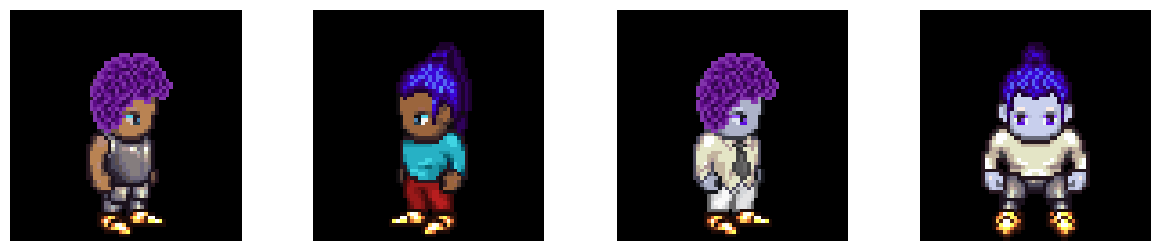

In [10]:
# 2. Data Diagnostics

data = CyclicSpritesDataModule(cfg.data)
data.setup('fit', cfg.training)

stats = data.get_data_stats()
print('Data stats (train/val/test keys may be present):', list(stats.keys()))
print('Sequence length (auto-detected):', stats.get('train', stats.get('test', {})).get('sequence_length'))

# Visualize a few sequences (first batch)
loader = data.val_dataloader()
batch = next(iter(loader))
if batch.dim() == 5:
    B, T, C, H, W = batch.shape
    fig, axes = plt.subplots(1, min(5, B), figsize=(15, 3))
    for i in range(min(5, B)):
        axes[i].imshow(batch[i, 0].permute(1, 2, 0).cpu().numpy())
        axes[i].axis('off')
    plt.show()
else:
    print('Unexpected batch shape:', batch.shape)



In [11]:
# 3. Model Build & Summary

# Build Lightning wrapper (includes ModularRiemannianFlowVAE)
trainer_wrapper = LightningRlVAETrainer(cfg, data_module=data)
model = trainer_wrapper.model

summary = model.get_model_summary() if hasattr(model, 'get_model_summary') else {}
print('Model summary keys:', list(summary.keys()) if isinstance(summary, dict) else type(summary))

# Encoder/Decoder arch info (from managers if available)
if hasattr(model, 'encoder_manager'):
    print('Encoder info:', model.encoder_manager.get_architecture_info())
if hasattr(model, 'decoder_manager'):
    print('Decoder info:', model.decoder_manager.get_architecture_info())



[DEBUG] model.metric config at model init: {'path': 'metric_T0.7_scaled.pt', 'temperature_override': 3.0}
[USER] Keeping n_flows = 8 (no sequence_length found)
✅ Created RiemannianFlowVAE with 8 IAF flows (via FlowManager)
🧠 Posterior type: riemannian_metric
[MODEL INIT] input_dim: [3, 64, 64], encoder architecture: mlp
🔍 DEBUG: Raw encoder config: {'architecture': 'mlp'}
🔍 DEBUG: Final encoder config: {'architecture': 'mlp'}
🔍 DEBUG: Encoder architecture: mlp
🔍 DEBUG: Raw decoder config: {'architecture': 'mlp'}
🔍 DEBUG: Final decoder config: {'architecture': 'mlp'}
🔍 DEBUG: Decoder architecture: mlp
✅ Created MLP encoder: 6308384 parameters
✅ Created MLP decoder: 6312448 parameters
✅ Created modular encoder: mlp
✅ Created modular decoder: mlp
✅ Initialized all modular components for ModularRiemannianFlowVAE
🔧 Loading encoder from: data/pretrained/encoder.pt
⚠️ Loaded pretrained encoder from: data/pretrained/encoder.pt (partial load)
✅ Loaded encoder weights
🔧 Loading decoder from: dat

Using metric module from model.modular_metric
Loading metric tensor from: /scratch/alaforgu/longitudinal_experiments/RlVAE/data/pretrained/metric_T0.7_scaled.pt
⚠️ Metric file latent_dim=2 != model metric latent_dim=16. Using temporary diagnostic metric.
✅ MetricTensor loaded: 50 centroids, T=0.500, λ=0.010
G_inv shape: torch.Size([8, 2, 2]) G shape: torch.Size([8, 2, 2]) log|G| shape: torch.Size([8])
Eigenvalue ranges across batch: 1.1751915 → 51.51425


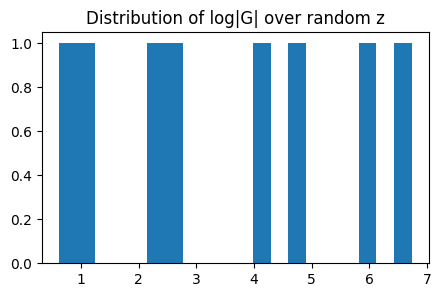

In [15]:
# 4. Metric Tensor Diagnostics (G, G⁻¹, logdet, eigenvalues)

# Locate a usable metric tensor module on the model
metric = None
candidate_names = ['modular_metric', 'metric', 'metric_tensor', 'G']
for name in candidate_names:
    if hasattr(model, name):
        candidate = getattr(model, name)
        if all(hasattr(candidate, fn) for fn in ['compute_inverse_metric', 'compute_metric', 'compute_log_det_metric']):
            metric = candidate
            print(f'Using metric module from model.{name}')
            break

# As a fallback, scan submodules
if metric is None:
    for m in model.modules():
        if all(hasattr(m, fn) for fn in ['compute_inverse_metric', 'compute_metric', 'compute_log_det_metric']):
            metric = m
            print('Using metric module discovered among model submodules')
            break

if metric is None:
    print('No metric tensor module found on model. Available attrs:', [a for a in dir(model) if 'metric' in a.lower() or a == 'G'])
else:
    # Ensure metric is loaded; if not, attempt to load from cfg
    is_loaded = getattr(metric, '_is_loaded', True)
    temp_metric = None
    if not is_loaded and hasattr(metric, 'load_pretrained'):
        # Prefer cfg.model.pretrained.metric_path; fallback to cfg.model.metric.path under data/pretrained
        metric_path = None
        try:
            if 'pretrained' in cfg.model and 'metric_path' in cfg.model.pretrained:
                metric_path = cfg.model.pretrained.metric_path
            elif 'metric' in cfg.model and 'path' in cfg.model.metric:
                metric_path = str((PROJECT_ROOT / 'data' / 'pretrained' / cfg.model.metric.path))
        except Exception:
            pass
        if metric_path is not None:
            from pathlib import Path as _Path
            from models.components.metric_tensor import MetricTensor
            mp = _Path(metric_path)
            if not mp.is_absolute():
                mp = (PROJECT_ROOT / mp).resolve()
            print('Loading metric tensor from:', mp)
            # Load state dict and call with tensors as required by MetricTensor.load_pretrained
            try:
                state = torch.load(str(mp), map_location=model.device)
            except Exception:
                # Handle PyTorch 2.6+ safe loading; fallback to unsafe if trusted
                try:
                    import numpy as _np
                    from torch.serialization import add_safe_globals as _add_safe_globals
                    _add_safe_globals([_np.core.multiarray._reconstruct])
                    state = torch.load(str(mp), map_location=model.device)
                except Exception:
                    state = torch.load(str(mp), map_location=model.device, weights_only=False)
            centroids = state.get('centroids', None)
            matrices = state.get('metric_matrices', None)
            if matrices is None:
                matrices = state.get('M_matrices', None)
            temperature = state.get('temperature', None)
            regularization = state.get('regularization', None)
            if centroids is None or matrices is None:
                print('⚠️ Could not find centroids/metric_matrices in file; skipping load.')
            else:
                # If dimensions mismatch with model latent_dim, use a temporary diagnostic metric
                if centroids.shape[1] != getattr(metric, 'latent_dim', centroids.shape[1]):
                    print(f"⚠️ Metric file latent_dim={centroids.shape[1]} != model metric latent_dim={getattr(metric,'latent_dim','?')}. Using temporary diagnostic metric.")
                    temp_metric = MetricTensor(latent_dim=centroids.shape[1], device=model.device)
                    temp_metric.load_pretrained(centroids, matrices, temperature, regularization)
                else:
                    metric.load_pretrained(centroids, matrices, temperature, regularization)
        else:
            print('Metric path not found in cfg; skipping load.')

    # Choose module to compute diagnostics with
    metric_module = temp_metric if temp_metric is not None else metric

    # Compute diagnostics
    latent_dim = getattr(metric_module, 'latent_dim', getattr(cfg.model, 'latent_dim', 16))
    z = torch.randn(8, latent_dim, device=model.device)
    G_inv = metric_module.compute_inverse_metric(z).detach().cpu()  # [B,d,d]
    G = metric_module.compute_metric(z).detach().cpu()               # [B,d,d]
    logdetG = metric_module.compute_log_det_metric(z).detach().cpu() # [B]
    print('G_inv shape:', G_inv.shape, 'G shape:', G.shape, 'log|G| shape:', logdetG.shape)

    # Eigenvalue stats
    vals = []
    for i in range(G.shape[0]):
        e = np.linalg.eigvalsh(G[i].numpy())
        vals.append(e)
    vals = np.array(vals)
    print('Eigenvalue ranges across batch:', vals.min(), '→', vals.max())

    plt.figure(figsize=(5,3))
    plt.hist(logdetG.numpy(), bins=20)
    plt.title('Distribution of log|G| over random z')
    plt.show()



In [17]:
# 5. Flow Diagnostics

flow_mgr = getattr(model, 'flow_manager', None)
if flow_mgr is None:
    print('No flow manager found (n_flows may be 0).')
else:
    print('n_flows:', getattr(cfg.model, 'n_flows', 'unknown'))
    total_params = sum(p.numel() for f in flow_mgr.flows for p in f.parameters())
    print('Total flow params:', total_params)



n_flows: 8
Total flow params: 2306560


In [18]:
# 6. Posterior RHMC Hooks (presence + quick exercise)

has_rhmc = hasattr(model, 'enable_pure_rhvae') or hasattr(model, 'G')
print('RHMC-related hooks found:', has_rhmc)

# If metric present, quick geodesic-vs-affine visualization seed (1D/2D latent suggested)
if metric is not None and getattr(cfg.model, 'latent_dim', 16) <= 3:
    z0 = torch.randn(1, metric.latent_dim)
    z1 = torch.randn(1, metric.latent_dim)
    # Affine interpolation
    ts = torch.linspace(0, 1, 25)
    affine = torch.stack([(1-t)*z0 + t*z1 for t in ts], dim=0).squeeze(1)
    # Placeholder for geodesic path (requires dedicated solver; here we reuse affine as placeholder)
    geodesic = affine.clone()
    plt.figure(figsize=(4,4))
    plt.plot(affine[:,0], affine[:,1], 'b.-', label='affine') if metric.latent_dim>=2 else None
    plt.title('Affine vs Geodesic (placeholder)')
    plt.legend()
    plt.show()



RHMC-related hooks found: True


In [19]:
# 7. Forward Pass Sanity

val_loader = data.val_dataloader()
xb = next(iter(val_loader))
res = model(xb, compute_metrics=True)
print('Output keys:', list(res.keys()))
for k in ['reconstruction','latent_samples','reconstruction_loss','kl_divergence','total_loss']:
    if k in res:
        v = res[k]
        if isinstance(v, torch.Tensor):
            print(k, 'shape' if v.dim()>0 else 'value', v.shape if v.dim()>0 else v.item())
        else:
            print(k, type(v))



[DEBUG] Validation DataLoader batch_size: 4


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

In [ ]:
# 8. Optional Fast Dev Training (very short)
from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping

run_short_train = False  # set True to run a tiny fit
if run_short_train:
    cfg.training.trainer.max_epochs = 2
    es = EarlyStopping(monitor='val_loss', patience=1, mode='min')
    tr = Trainer(max_epochs=cfg.training.trainer.max_epochs,
                 accelerator=cfg.training.trainer.accelerator,
                 devices=cfg.training.trainer.devices,
                 callbacks=[es],
                 enable_progress_bar=True)
    tr.fit(trainer_wrapper, data)



In [ ]:
# 9. Metric Normalizer log Z(ψ) via anchors (estimator)

def estimate_logZ(metric_module, anchors: torch.Tensor):
    with torch.no_grad():
        logdet = metric_module.compute_log_det_metric(anchors)  # shape [N]
        # log Z ≈ log E[exp(0.5 * log|G|)] = log mean sqrt(|G|)
        vals = 0.5 * logdet
        m = vals.max()
        return (m + torch.log(torch.mean(torch.exp(vals - m)))).item()

if metric is not None:
    N = 2048
    anchors = torch.randn(N, metric.latent_dim, device=model.device)
    logZ_hat = estimate_logZ(metric, anchors)
    print('Estimated log Z(ψ):', logZ_hat)
else:
    print('Metric not available; skipping logZ estimate.')



In [ ]:
# 11. Quick Checks & Exports

print('Visualization modules enabled:', list(getattr(trainer_wrapper, 'viz_manager', {}).modules.keys()) if getattr(trainer_wrapper, 'viz_manager', None) else [])

# Save a tiny summary file
out_dir = PROJECT_ROOT / 'outputs' / 'diagnostics'
out_dir.mkdir(parents=True, exist_ok=True)
summary_file = out_dir / 'summary.txt'
with open(summary_file, 'w') as f:
    f.write('CUDA available: %s\n' % torch.cuda.is_available())
    f.write('Config:\n')
    f.write(OmegaConf.to_yaml(cfg))
print('Wrote:', summary_file)

